# Installing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords, wordnet
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       d

True

# 1. Data Exploration and Preprocessing

In [3]:
data = pd.read_csv("data/training_data/train_data with labels.csv")
data.head()

,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


In [4]:
def text_process(text):
  # Handle non-string values gracefully
    if not isinstance(text, str):
        return ""

    # Define a set of stopwords, including standard English stopwords and some custom ones
    STOPWORDS = stopwords.words('english') + ['u', 'ü', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure', "id"]

    # Remove punctuation from the tweet
    nopunc = ''.join([char for char in text if char not in string.punctuation])

    # Remove stopwords and join the words back into a string
    return ' '.join([word for word in nopunc.split() if word.lower() not in STOPWORDS])

In [5]:
data['clean_text'] = data['text'].apply(text_process)

In [6]:
lemmatizer = WordNetLemmatizer()
data['text_tokens'] = data['clean_text'].apply(word_tokenize)
data['lemmatized'] = data['text_tokens'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
data['lemmatized_text'] = data['lemmatized'].apply(lambda tokens: ' '.join(tokens))

In [7]:
X = data['lemmatized_text']
y = data['label']

# 2. Feature Engineering

# Feature Engineering: TF-IDF

In [8]:
vectorizer = TfidfVectorizer(stop_words = "english", token_pattern=r"(?u)\b\w+\b")
X_vector = vectorizer.fit_transform(X)

# Feature Engineering: GloVe

In [9]:
glove = {}

with open("models/embedding_model/glove.6B.50d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype="float32")
        glove[word] = vector

In [10]:
def get_glove_embedding(tokens):
    vectors = []

    for word in tokens:
        word = word.lower()

        if word in glove:
            vectors.append(glove[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

In [11]:
X_glove = np.array(
    data["lemmatized_text"].apply(get_glove_embedding).tolist()
)
X_glove.shape

(8176, 50)

# Train Test Split for both TF-IDF and GloVe

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_vector, y, test_size=0.2, random_state=42)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_glove, y, test_size=0.2, random_state=42)

# 3. Model Training and Tuning

# SVM Model training with TF-IDF

In [13]:
svmodel = svm.SVC(C=10, kernel='linear')
svmodel.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# SVM Model Training with GloVe

In [14]:
svmodel1 = svm.SVC(C=10, kernel='linear')
svmodel1.fit(X_train1, y_train1)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# GridSearchCV for Decision Tree Model
Commented out because it takes too long to complete so after running once, I collect the best parameters and use them

In [15]:
#dt_grid_params = {'max_depth': [1,3,5,10], 'min_samples_split': [2, 4, 6, 10]}
#dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_grid_params, refit=True, verbose=3)
#dt_grid.fit(X_train, y_train)

In [16]:
#print(dt_grid.best_params_)

# Decision Tree Model Training with TF-IDF

In [17]:
dtmodel = DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42)
dtmodel.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

# Decision Tree Model Training with GloVe

In [18]:
dtmodel1 = DecisionTreeClassifier(max_depth=10, min_samples_split=4, random_state=42)
dtmodel1.fit(X_train1, y_train1)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

# GridSearchCV for AdaBoost Model
Commented out because it takes too long to complete so after running once, I collect the best parameters and use them

In [19]:
#ada_grid_params = {
#    'n_estimators': [25, 50, 75, 100],
#    'learning_rate': [1.0, 2.0, 3.0]
#}
#adagrid = GridSearchCV(AdaBoostClassifier(), ada_grid_params, refit=True, verbose=3)
#adagrid.fit(X_train, y_train)

In [20]:
#print(adagrid.best_params_)

# AdaBoost Model Training with TF-IDF

In [21]:
adamodel = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
adamodel.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


# AdaBoost Model Training with GloVe

In [22]:
adamodel1 = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
adamodel1.fit(X_train1, y_train1)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


# Feedforward Neural Network Model Training with TF-IDF
2 hidden layers with 128 neurons in each and a dropout of 0.2, 2 outputs and a softmax activation function for the output, hidden layers use the relu activation function

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

fnn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),                # Drop 20% of neurons
    Dense(128, activation='relu'),
    Dropout(0.3),                # Drop 20% again
    Dense(2, activation='softmax')
])

fnn.compile(optimizer=Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

fnn.fit(X_train, y_train, epochs=5)

Epoch 1/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - loss: 0.2336 - sparse_categorical_accuracy: 0.9162
Epoch 2/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - loss: 0.0177 - sparse_categorical_accuracy: 0.9948
Epoch 3/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - loss: 0.0048 - sparse_categorical_accuracy: 0.9983
Epoch 4/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - loss: 8.6357e-04 - sparse_categorical_accuracy: 0.9998
Epoch 5/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 2.8171e-04 - sparse_categorical_accuracy: 1.0000


# Feedforward Neural Network Model Training with GloVe
2 hidden layers with 128 neurons in each and a dropout of 0.2, 2 outputs and a softmax activation function for the output, hidden layers use the relu activation function

In [24]:
fnn1 = Sequential([
    Input(shape=(X_train1.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),                # Drop 20% of neurons
    Dense(128, activation='relu'),
    Dropout(0.3),                # Drop 20% again
    Dense(2, activation='softmax')
])

fnn1.compile(optimizer=Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

fnn1.fit(X_train1, y_train1, epochs=5)

Epoch 1/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6974 - sparse_categorical_accuracy: 0.5173
Epoch 2/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6895 - sparse_categorical_accuracy: 0.5417
Epoch 3/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6867 - sparse_categorical_accuracy: 0.5466
Epoch 4/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6768 - sparse_categorical_accuracy: 0.5838
Epoch 5/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6699 - sparse_categorical_accuracy: 0.5948


# LSTM (Long Short Term Memory) Model Training
From neural network creation to, compiling then fitting

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = data['lemmatized_text']
y = data['label']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train2)

X_train_seq = tokenizer.texts_to_sequences(X_train2)
X_test_seq = tokenizer.texts_to_sequences(X_test2)

max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=10000, output_dim=100),
    LSTM(64),
    Dropout(0.3),
    Dense(2, activation="softmax")
])

model.compile(optimizer=Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

model.fit(
    X_train_pad,
    y_train,
    epochs=5,
)

Epoch 1/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - loss: 0.5819 - sparse_categorical_accuracy: 0.6826
Epoch 2/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.5165 - sparse_categorical_accuracy: 0.7317
Epoch 3/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 0.4161 - sparse_categorical_accuracy: 0.7833
Epoch 4/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 0.3796 - sparse_categorical_accuracy: 0.7982
Epoch 5/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - loss: 0.2988 - sparse_categorical_accuracy: 0.8787


# CNN (Convolutional Neural Network) Model
From neural network creation to, compiling then fitting

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

cnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=10000, output_dim=100),

    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),

    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

In [27]:
cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
cnn.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.7496 - loss: 0.4635 - val_accuracy: 0.9343 - val_loss: 0.1720
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9608 - loss: 0.1110 - val_accuracy: 0.9625 - val_loss: 0.0998
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9933 - loss: 0.0246 - val_accuracy: 0.9641 - val_loss: 0.1060
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 0.9687 - val_loss: 0.1130
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9981 - loss: 0.0066 - val_accuracy: 0.9633 - val_loss: 0.1291


# 4. Evaluation and Comparison

# SVM model evaluation: TF-IDF vs. GloVe

In [29]:
y_svmpred = svmodel.predict(X_test)

In [30]:
y_svmpred1 = svmodel1.predict(X_test1)

# SVM TF-IDF Evaluation

0.9712713936430318
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       811
           1       0.97      0.97      0.97       825

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636

[[789  22]
 [ 25 800]]


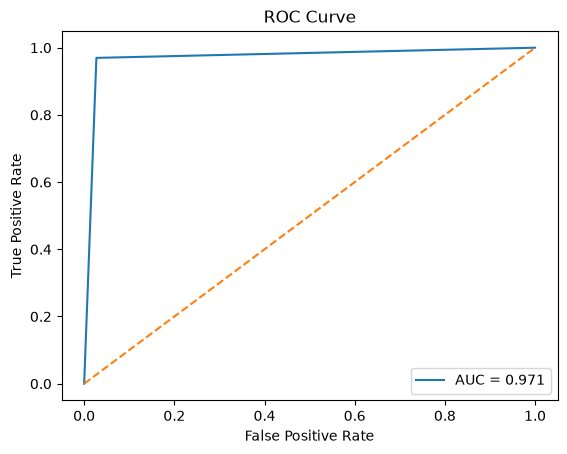

In [31]:
print(accuracy_score(y_test, y_svmpred))
print(classification_report(y_test, y_svmpred))
print(confusion_matrix(y_test, y_svmpred))

fpr, tpr, thresholds = roc_curve(y_test, y_svmpred)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# SVM GloVe Evaluation

0.7671149144254279
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       811
           1       0.81      0.70      0.75       825

    accuracy                           0.77      1636
   macro avg       0.77      0.77      0.77      1636
weighted avg       0.77      0.77      0.77      1636

[[678 133]
 [248 577]]


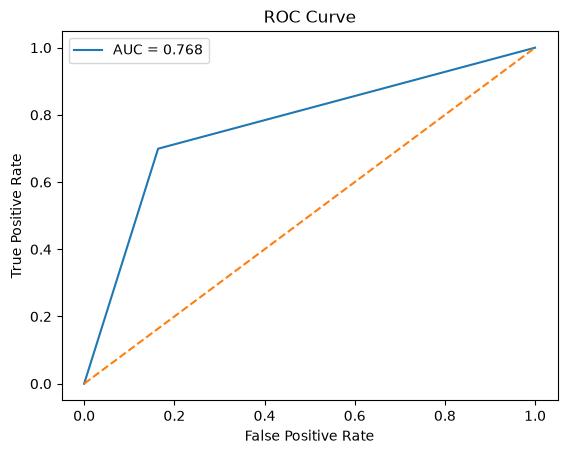

In [32]:
print(accuracy_score(y_test1, y_svmpred1))
print(classification_report(y_test1, y_svmpred1))
print(confusion_matrix(y_test1, y_svmpred1))

fpr, tpr, thresholds = roc_curve(y_test1, y_svmpred1)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Decision Tree Model Evaluation TF-IDF vs GloVe

# Decision Tree TF-IDF Evaluation

0.902200488997555
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       811
           1       0.89      0.92      0.90       825

    accuracy                           0.90      1636
   macro avg       0.90      0.90      0.90      1636
weighted avg       0.90      0.90      0.90      1636

[[718  93]
 [ 67 758]]


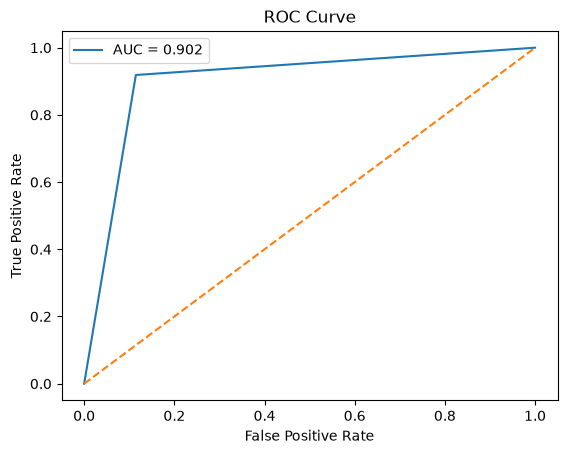

In [33]:
dtpred = dtmodel.predict(X_test)
print(accuracy_score(y_test, dtpred))
print(classification_report(y_test, dtpred))
print(confusion_matrix(y_test, dtpred))

fpr, tpr, thresholds = roc_curve(y_test, dtpred)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Decision Tree GloVe Evaluation

0.6992665036674817
              precision    recall  f1-score   support

           0       0.70      0.69      0.69       811
           1       0.70      0.71      0.70       825

    accuracy                           0.70      1636
   macro avg       0.70      0.70      0.70      1636
weighted avg       0.70      0.70      0.70      1636

[[560 251]
 [241 584]]


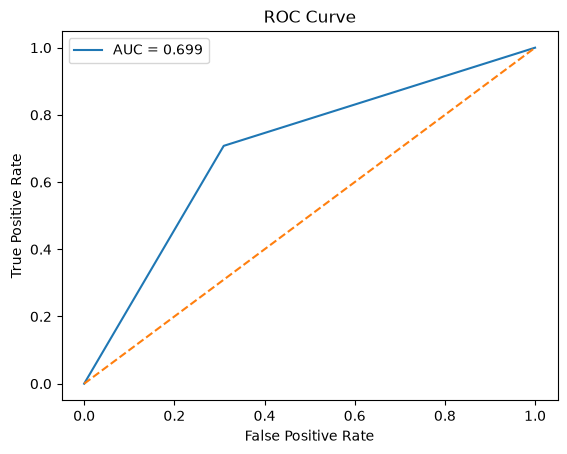

In [34]:
dtpred1 = dtmodel1.predict(X_test1)
print(accuracy_score(y_test1, dtpred1))
print(classification_report(y_test1, dtpred1))
print(confusion_matrix(y_test1, dtpred1))

fpr, tpr, thresholds = roc_curve(y_test1, dtpred1)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# AdaBoost Model Evaluation TF-IDF vs GloVe

# AdaBoost Model TF-IDF Evaluation

0.9523227383863081
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       811
           1       0.95      0.96      0.95       825

    accuracy                           0.95      1636
   macro avg       0.95      0.95      0.95      1636
weighted avg       0.95      0.95      0.95      1636

[[768  43]
 [ 35 790]]


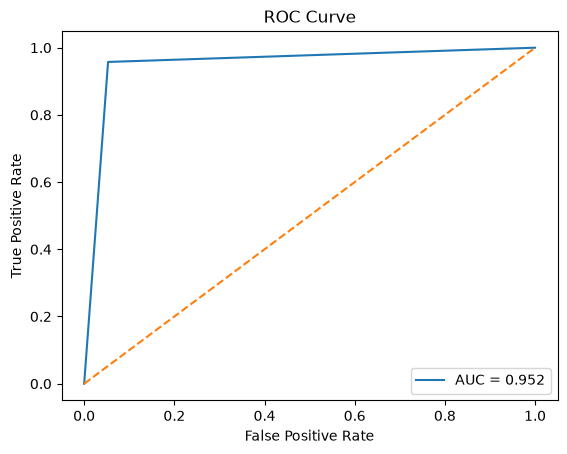

In [35]:
adapred = adamodel.predict(X_test)
print(accuracy_score(y_test, adapred))
print(classification_report(y_test, adapred))
print(confusion_matrix(y_test, adapred))

fpr, tpr, thresholds = roc_curve(y_test, adapred)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# AdaBoost Model Evaluation GloVe

0.7426650366748166
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       811
           1       0.76      0.72      0.74       825

    accuracy                           0.74      1636
   macro avg       0.74      0.74      0.74      1636
weighted avg       0.74      0.74      0.74      1636

[[621 190]
 [231 594]]


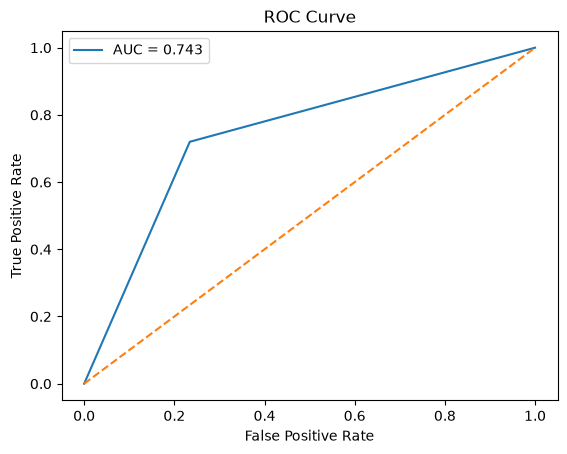

In [36]:
adapred1 = adamodel1.predict(X_test1)
print(accuracy_score(y_test1, adapred1))
print(classification_report(y_test1, adapred1))
print(confusion_matrix(y_test1, adapred1))

fpr, tpr, thresholds = roc_curve(y_test1, adapred1)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# FeedForward Neural Network Model Evaluation TF-IDF vs GloVe

# FeedForward Neural Network Model Evaluation TF-IDF

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
0.965158924205379
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       811
           1       0.96      0.97      0.97       825

    accuracy                           0.97      1636
   macro avg       0.97      0.97      0.97      1636
weighted avg       0.97      0.97      0.97      1636

[[782  29]
 [ 28 797]]


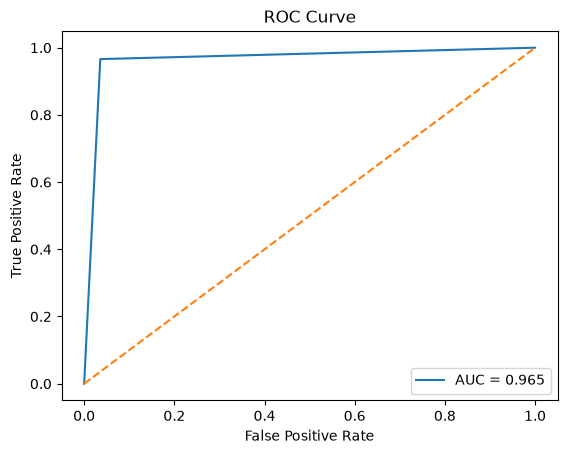

In [37]:
fnnpred = fnn.predict(X_test)
fnnpred = fnnpred.argmax(axis=1)
print(accuracy_score(y_test, fnnpred))
print(classification_report(y_test, fnnpred))
print(confusion_matrix(y_test, fnnpred))

fpr, tpr, thresholds = roc_curve(y_test, fnnpred)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# FeedForward Neural Network Model Evaluation GloVe

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.628361858190709
              precision    recall  f1-score   support

           0       0.60      0.77      0.67       811
           1       0.68      0.49      0.57       825

    accuracy                           0.63      1636
   macro avg       0.64      0.63      0.62      1636
weighted avg       0.64      0.63      0.62      1636

[[622 189]
 [419 406]]


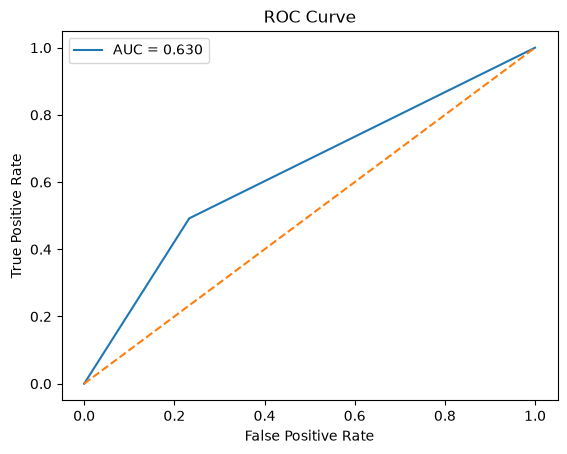

In [38]:
fnnpred1 = fnn1.predict(X_test1)
fnnpred1 = fnnpred1.argmax(axis=1)
print(accuracy_score(y_test1, fnnpred1))
print(classification_report(y_test1, fnnpred1))
print(confusion_matrix(y_test1, fnnpred1))

fpr, tpr, thresholds = roc_curve(y_test1, fnnpred1)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Long Short Term Memory Model Evaluation

In [39]:
lstm_prob = model.predict(X_test_pad)
lstm_pred = lstm_prob.argmax(axis=1)

52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


0.8973105134474327
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       811
           1       0.87      0.94      0.90       825

    accuracy                           0.90      1636
   macro avg       0.90      0.90      0.90      1636
weighted avg       0.90      0.90      0.90      1636

[[692 119]
 [ 49 776]]


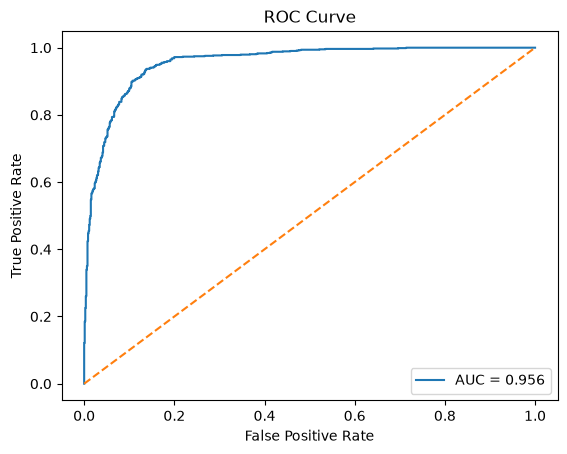

In [40]:
print(accuracy_score(y_test, lstm_pred))
print(classification_report(y_test, lstm_pred))
print(confusion_matrix(y_test, lstm_pred))

fpr, tpr, thresholds = roc_curve(y_test, lstm_prob[:, 1])

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guessing line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Convolutional Neural Network Model Evaluation

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
0.9639364303178484
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       811
           1       0.95      0.97      0.96       825

    accuracy                           0.96      1636
   macro avg       0.96      0.96      0.96      1636
weighted avg       0.96      0.96      0.96      1636

[[773  38]
 [ 21 804]]


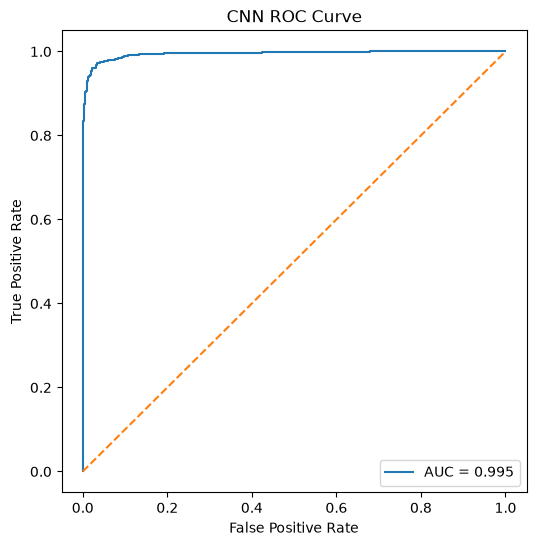

In [41]:
cnn_prob = cnn.predict(X_test_pad).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

print(accuracy_score(y_test, cnn_pred))
print(classification_report(y_test, cnn_pred))
print(confusion_matrix(y_test, cnn_pred))

fpr, tpr, thresholds = roc_curve(y_test, cnn_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")
plt.legend()

plt.show()

# Feature Comparison: TF-IDF vs. GloVe Word Embeddings

This project compared two feature extraction techniques for AI-generated text detection: TF-IDF and GloVe word embeddings. TF-IDF represents documents using the frequency and importance of words within the dataset, while GloVe represents words as dense vectors that capture semantic relationships.

The experimental results showed that TF-IDF significantly outperformed GloVe across all evaluated models. Using TF-IDF features, the SVM achieved 97% accuracy compared to 77% with GloVe. Decision Tree achieved 90% accuracy with TF-IDF but only 70% with GloVe. AdaBoost improved from 74% using GloVe to 95% using TF-IDF. The largest difference was observed with the Feedforward Neural Network, which achieved 97% accuracy with TF-IDF but only 54% accuracy with GloVe.

One possible explanation is that AI-generated text detection relies heavily on specific vocabulary usage, phrase frequency, and stylistic patterns. TF-IDF preserves this lexical information directly, allowing the models to learn which words and phrases are most indicative of AI-generated text. In contrast, GloVe compresses each document into a fixed-length semantic representation, which may remove important stylistic information needed for classification.

Overall, TF-IDF proved to be the superior feature extraction method for this task and dataset.

| Model         | Features | Accuracy | ROC AUC |
| ------------- | -------- | -------- | ------- |
| SVM           | TF-IDF   | 0.97     | 0.971   |
| Decision Tree | TF-IDF   | 0.90     | 0.902   |
| AdaBoost      | TF-IDF   | 0.95     | 0.952   |
| FNN           | TF-IDF   | 0.97     | 0.971   |
| LSTM          | TF-IDF   | 0.82     | 0.879   |
| CNN           | TF-IDF   | 0.97     | 0.995   |
| SVM           | GloVe    | 0.77     | 0.768   |
| Decision Tree | GloVe    | 0.70     | 0.699   |
| AdaBoost      | GloVe    | 0.74     | 0.743   |
| FNN           | GloVe    | 0.54     | 0.541   |


# Machine Learning vs. Deep Learning

This project evaluated both traditional machine learning algorithms and deep learning architectures for AI-generated text detection. The machine learning models included Support Vector Machine (SVM), Decision Tree, and AdaBoost, while the deep learning models included a Feedforward Neural Network (FNN), Long Short-Term Memory network (LSTM), and Convolutional Neural Network (CNN).

The results demonstrated that both approaches can achieve strong performance when paired with effective feature extraction. SVM achieved 97% accuracy and an ROC-AUC score of 0.971, while CNN achieved 97% accuracy and the highest ROC-AUC score of 0.995. The Feedforward Neural Network also achieved 97% accuracy. In contrast, the LSTM achieved only 82% accuracy, making it the weakest-performing deep learning model.

These findings suggest that increasing model complexity does not necessarily guarantee improved performance. For this task, AI-generated text appears to be distinguishable through vocabulary and phrase usage patterns, which are effectively captured by TF-IDF features. As a result, simpler machine learning models such as SVM were able to match or exceed the performance of more complex neural network architectures.


# Speed vs. Accuracy Trade-Off, Best Model, Limitations, and Conclusions

A key observation from this project is the trade-off between computational complexity and predictive performance. Simpler models such as Decision Trees train quickly and require fewer computational resources, but their classification performance was lower than that of SVM, CNN, and FNN. Deep learning models required additional training time and parameter tuning but were capable of achieving competitive performance when properly configured.

Among all evaluated models, the CNN achieved the strongest overall performance. Although SVM and FNN achieved similar accuracy scores of approximately 97%, the CNN achieved the highest ROC-AUC score of 0.995, indicating superior ability to distinguish between AI-generated and human-written text across different classification thresholds. This suggests that the CNN was able to learn highly informative local text patterns useful for classification.

Several limitations were observed during testing. Short text samples may contain insufficient information for reliable classification, while highly polished human-written text can sometimes resemble AI-generated content. Similarly, carefully prompted AI-generated text may appear more human-like and reduce detection accuracy. These limitations demonstrate that AI text detectors should be viewed as decision-support tools rather than definitive indicators of authorship.

In a classroom environment, this system could serve as a useful screening tool to identify assignments that warrant additional review. However, the predictions should not be used as the sole basis for academic integrity decisions. Human judgment, writing history, and additional evidence should be considered before drawing conclusions about authorship.

Overall, the project demonstrated that feature engineering plays a critical role in text classification performance. TF-IDF combined with strong classifiers such as SVM and CNN produced the best results, significantly outperforming GloVe-based representations. The findings suggest that preserving lexical and stylistic information is highly important for distinguishing AI-generated text from human-written text.


# Saving Models and Tokenizers with Pickle

In [42]:
import pickle

# TF-IDF vectorizer
pickle.dump(vectorizer, open("models/tfidfvectorizer.pkl", "wb"))

# sklearn models
pickle.dump(svmodel, open("models/svm.pkl", "wb"))
pickle.dump(dtmodel, open("models/decision_tree.pkl", "wb"))
pickle.dump(adamodel, open("models/adaboost.pkl", "wb"))

# Keras tokenizer for LSTM/CNN
pickle.dump(tokenizer, open("models/tokenizer.pkl", "wb"))

fnn.save("models/fnn_model.keras")
model.save("models/lstm_model.keras")
cnn.save("models/cnn_model.keras")

train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

train_df.to_csv("data/training_data/train_data.csv", index=False)
test_df.to_csv("data/test_data/test_data.csv", index=False)